# Decision Trees & Random Forest

### Decision Trees
A Decision Tree algorithm is one of the most popular machine learning algorithms. It belongs to the class of supervised learning algorithms where it can be used for both classification and regression purposes. Nowadays, Decision Tree algorithm is known by its modern name $\bold{CART}$ which stands for Classification and Regression Trees.

In [1]:
# inporting essential libraries
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from graphviz import Digraph
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
import warnings
warnings.filterwarnings('ignore')

In [2]:
col_names = ["sepal_length", "sepal_width", "petal_length", "petal_width", "type"]
df = pd.read_csv(r"D:\git things\Machine-Vision-Projects\Datasets\iris\Iris.csv", skiprows=1, names=col_names)
df['type'] = df['type'].map({'Iris-setosa': 0,'Iris-versicolor': 1,'Iris-virginica': 2})
df.head()

,sepal_length,sepal_width,petal_length,petal_width,type
1,5.1,3.5,1.4,0.2,0
2,4.9,3.0,1.4,0.2,0
3,4.7,3.2,1.3,0.2,0
4,4.6,3.1,1.5,0.2,0
5,5.0,3.6,1.4,0.2,0


### Entropy
Entropy is a measure of uncertainty or impurity in a dataset. It quantifies how mixed the class labels are in a given set of samples.  
A dataset with only one class has zero entropy (pure), while a dataset with a uniform distribution of classes has maximum entropy.  
The entropy is defined as:
$$
\textrm{Entropy} (E) = - \sum_{i=1}^{c}{p_i log(p_i)}
$$
$p_i$ = Probability of class $i$ in the node  
$c$ = Total number of classes in the node

### Gini Impurity
Gini Impurity measures the likelihood of incorrectly classifying a randomly chosen element if it was randomly labeled according to the class distribution.  
A Gini Impurity of 0 indicates a perfectly pure dataset, while higher values indicate more impurity.  
It is defined as:
$$
\textrm{Gini Index} (G) = 1 - \sum_{i=1}^{c}{p_i^2}
$$
$p_i$ = Probability of class $i$ in the node  
$c$ = Total number of classes in the node

### Information Gain or Gini Gain
Information Gain / Gini Gain measures the reduction in entropy / Gini Impurity after a dataset is split on a feature. It helps determine the best feature to split the data in a decision tree.  
A higher Information Gain / Gini Gain indicates a more effective split.  
It is calculated as:
$$
IG = E(parent) - \sum{w_i E({child}_i)} \qquad GG = G(parent) - \sum{w_i G({child}_i)}
$$

$w_i = \frac{\textrm{number of data points in the child}}{\textrm{number of data points in the parent}}$

### Implementing Decision Tree Algorithm using Python OOP

In [3]:
class Node():
    def __init__(self, feature_index=None, threshold=None, left=None, right=None, info_gain=None, value=None):

        # for decision node
        self.feature_index = feature_index
        self.threshold = threshold
        self.left = left
        self.right = right
        self.info_gain = info_gain

        # for leaf node
        self.value = value

In [4]:
class DecisionTreeClassifier_(): 
    def __init__(self, min_samples_split=2, max_depth=2):

        # initialize the root of the tree
        self.root = None

        # stopping conditions
        self.min_samples_split = min_samples_split
        self.max_depth = max_depth
    
    def build_tree(self, dataset, curr_depth=0):

        X, Y = dataset[:,:-1], dataset[:,-1]
        num_samples, num_features = np.shape(X)

        # split until stopping conditions are met
        if num_samples >= self.min_samples_split and curr_depth <= self.max_depth:
            # find the best split
            best_split = self.get_best_Split(dataset, num_samples, num_features)
            # check if information gain is positive
            if best_split["info_gain"] > 0:
                # recur left
                left_subtree = self.build_tree(best_split["dataset_left"], curr_depth+1)
                # recur right
                right_subtree = self.build_tree(best_split["dataset_right"], curr_depth+1)
                # return decision node
                return Node(best_split["feature_index"], best_split["threshold"], left_subtree, right_subtree, best_split["info_gain"])
        # compute leaf node
        leaf_value = self.calculate_leaf_value(Y)
        # return leaf node
        return Node(value=leaf_value)
    
    def get_best_Split(self, dataset, num_samples, num_features):

        # dictionary to store the best split
        best_split = {}
        max_info_gain = -float("inf")

        # loop over all the features
        for feature_index in range(num_features):
            feature_values = dataset[:, feature_index]
            possible_thresholds = np.unique(feature_values)
            # loop over all the feature values present in the data
            for threshold in possible_thresholds:
                # get current split
                dataset_left, dataset_right = self.split(dataset, feature_index, threshold)
                # check if childs are not null
                if len(dataset_left) > 0 and len(dataset_right) > 0:
                    y, left_y, right_y = dataset[:,-1], dataset_left[:,-1], dataset_right[:,-1]
                    # compute information gain
                    curr_info_gain = self.information_gain(y, left_y, right_y, "gini")
                    # update the best split if needed
                    if curr_info_gain > max_info_gain:
                        best_split["feature_index"] = feature_index
                        best_split["threshold"] = threshold
                        best_split["dataset_left"] = dataset_left
                        best_split["dataset_right"] = dataset_right
                        best_split["info_gain"] = curr_info_gain
                        max_info_gain = curr_info_gain

        # return best split
        return best_split
    
    def split(self, dataset, feature_index, threshold):
        dataset_left = np.array([row for row in dataset if row[feature_index] <= threshold])
        dataset_right = np.array([row for row in dataset if row[feature_index] > threshold])
        return dataset_left, dataset_right

    def information_gain(self, parent, l_child, r_child, mode="entropy"):
        weight_l = len(l_child) / len(parent)
        weight_r = len(r_child) / len(parent)
        if mode == "gini":
            gain = self.gini_index(parent) - (weight_l*self.gini_index(l_child) + weight_r*self.gini_index(r_child))
        else:
            gain = self.entropy(parent) - (weight_l*self.entropy(l_child) + weight_r*self.entropy(r_child))
        return gain

    def entropy(self, y):
        class_labels = np.unique(y)
        entropy = 0
        for cls in class_labels:
            p_cls = len(y[y == cls]) / len(y)
            entropy += -p_cls * np.log2(p_cls)
        return entropy

    def gini_index(self, y):
        class_labels = np.unique(y)
        gini = 0
        for cls in class_labels:
            p_cls = len(y[y == cls]) / len(y)
            gini += p_cls**2
        return 1 - gini
    
    def calculate_leaf_value(self, Y):
        Y = list(Y)
        return max(Y, key=Y.count)
    
    def print_visualize_tree(self):
        dot = Digraph()
        dot.attr(size="1.5,1.5")
        dot.attr(dpi="300")
        def add_nodes_edges(tree, parent=None, edge_label=""):
            if tree is None:
                return
            node_id = str(id(tree))
            if tree.value is not None:
                label = f"Class: {int(tree.value)}"
                dot.node(node_id, label, shape="box")
            else:
                label = f"X{tree.feature_index} <= {tree.threshold}\nIG: {tree.info_gain:.4f}"
                dot.node(node_id, label)
            if parent is not None:
                dot.edge(parent, node_id, label=edge_label)
            if tree.left is not None:
                add_nodes_edges(tree.left, node_id, "Left")
            if tree.right is not None:
                add_nodes_edges(tree.right, node_id, "Right")
        add_nodes_edges(self.root)
        return dot

    def fit(self, X, Y):
        dataset = np.concatenate((X, Y), axis=1)
        self.root = self.build_tree(dataset)
    
    def predict(self, X):
        predictions = [self.make_prediction(x, self.root) for x in X]
        return predictions
    
    def make_prediction(self, x, tree):
        if tree.value != None:
            return tree.value
        feature_val = x[tree.feature_index]
        if feature_val <= tree.threshold:
            return self.make_prediction(x, tree.left)
        else:
            return self.make_prediction(x, tree.right)

Spliting into Train & Test Datasets

In [5]:
X = df.iloc[:, :-1].values
Y = df.iloc[:, -1].values.reshape(-1, 1)
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=41)
print("Train dataset : X -->", X_train.shape, "Y -->", Y_train.shape)
print("Test dataset : X -->", X_test.shape, "Y -->", Y_test.shape)

Train dataset : X --> (120, 4) Y --> (120, 1)
Test dataset : X --> (30, 4) Y --> (30, 1)


Fitting the Model & Displaying the Decision Tree

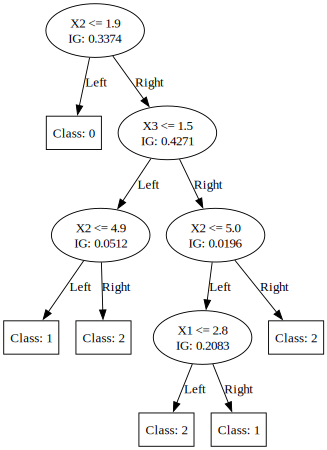

In [6]:
classifier = DecisionTreeClassifier_(min_samples_split=3, max_depth=3)
classifier.fit(X_train, Y_train)
dot = classifier.print_visualize_tree()
display(dot)

Testing the Model

In [7]:
Y_pred = classifier.predict(X_test)
print("Accuracy:", accuracy_score(Y_test, Y_pred))

Accuracy: 0.9333333333333333


### Decision Tree Algorithm in Scikit-learn

In [8]:
model = DecisionTreeClassifier(criterion='gini', max_depth=3, random_state=42)
model.fit(X_train, Y_train)
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(Y_test, y_pred))

Accuracy: 0.8333333333333334


### Random Forest

Random Forest is an ensemble learning method that constructs multiple decision trees during training and combines their outputs to improve overall performance and reduce overfitting. Each tree is trained on a different subset of the data and features, making the model more robust and less sensitive to noise compared to a single decision tree.

Bootstrapping is a sampling technique where multiple datasets are created by randomly sampling the original dataset with replacement. Each decision tree in a random forest is trained on a different bootstrapped dataset, ensuring diversity among the trees and improving generalization.

Feature Selection in Random Forest refers to the process of selecting a random subset of features at each split in a decision tree. Instead of considering all features, only a small random subset is evaluated to determine the best split. This introduces additional randomness, reduces correlation among trees, and enhances model performance.

Majority Voting is the method used in random forest classification to combine predictions from multiple decision trees. Each tree outputs a class prediction, and the final prediction is the class that receives the highest number of votes across all trees.

### Example: Constructing a Random Forest

Consider a dataset $D$ with $N$ samples and $M$ features. A Random Forest is an ensemble of $K$ decision trees, where each tree is trained on a different variation of the dataset. Multiple datasets $\{D_1, D_2, \dots, D_K\}$ are generated by sampling from $D$ with replacement. Each dataset is used to train a separate decision tree. For each dataset $D_k$, a decision tree $T_k$ is trained. At each split, a random subset of features of size $m$ (where $m < M$) is selected, and the best split is chosen using a criterion such as Gini impurity or entropy. ($M = $ Total Number of features in the dataset)

For a new input sample $x$, each tree produces a prediction:
$$
\hat{y}_k = T_k(x), \quad k = 1,2,\dots,K
$$

The final prediction is obtained by combining the outputs of all trees using majority voting:
$$
\hat{y} = \text{mode}(\hat{y}_1, \hat{y}_2, \dots, \hat{y}_K)
$$

Suppose we have three decision trees with predictions:
$$
T_1(x) = 1, \quad T_2(x) = 0, \quad T_3(x) = 1
$$

Then, the final prediction becomes:
$$
\hat{y} = \text{mode}(1, 0, 1) = 1
$$

Thus, the Random Forest combines multiple decision trees to produce a more accurate and stable prediction.

In [9]:
# n_estimators is the number of trees
model = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
model.fit(X_train, Y_train)
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(Y_test, y_pred))

Accuracy: 0.9
